# AI2008 - Group 7 - AI-Driven Dynamic Pricing in Freight & Shipping Logistics

## 0. Cài đặt môi trường

Trong dự án nghiên cứu về **AI-Driven Dynamic Pricing in Freight & Shipping Logistics**, nhóm đã thiết lập các thư viện sau:

1.  **Pandas**: Dùng để cấu trúc hóa dữ liệu từ file .csv thành DataFrame và thực hiện các thao tác biến đổi dữ liệu.
2.  **NumPy**: Hỗ trợ tính toán ma trận và các hàm toán học phức tạp cho thuật toán định giá.
3.  **SQLite3**: Quản trị cơ sở dữ liệu quan hệ tích hợp sẵn trong Python, giúp lưu trữ và truy vấn dữ liệu.
4.  **Matplotlib/Seaborn**: Hỗ trợ trực quan hóa các xu hướng giá.

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra phiên bản các thư viện chính
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SQLite3 version: {sqlite3.sqlite_version}")

# Khởi tạo kết nối SQLite (tạo file database local)
conn = sqlite3.connect('freight_pricing_research.db')

print("\n--- Môi trường đã được cài đặt thành công ---")

Pandas version: 3.0.3
NumPy version: 2.5.0
SQLite3 version: 3.50.4

--- Môi trường đã được cài đặt thành công ---


## 1. Nhập và Kiểm tra Dataset (Dataset Loading & Exploration)

Trong phần này, nhóm sẽ thực hiện các bước sau:
1. Tải tập dữ liệu nghiên cứu từ file CSV (`DataCoSupplyChainDataset.csv`) - chương trình sẽ tự detect xem dataset có tồn tại trong file path được lưu trên Google Drive hay không - hoặc dataset có được tải lên trên đây hay không.
2. Chuyển đổi dữ liệu vào Pandas DataFrame để dễ dàng thao tác.
3. Xem trước 5 dòng đầu tiên để hiểu cấu trúc các cột như `Shipping Mode`, `Sales`, `Order Region`, và `Delivery Status`.

In [4]:
import os
import pandas as pd

# Tạo thư mục lưu trữ biểu đồ nếu chưa tồn tại
os.makedirs('charts_img', exist_ok=True)

# Tên file dataset
filename = 'DataCoSupplyChainDataset.csv'

# Kiểm tra file ở thư mục hiện tại trước, sau đó mới đến Google Drive
if os.path.exists(filename):
    file_path = filename
    print(f"Use as local: {file_path}")
else:
    file_path = filename # Đường dẫn local
    print("Error: Can not find dataset file. Please upload file to Colab.")

# Tiến hành đọc file CSV (180519 dòng x 53 cột)
try:
    df = pd.read_csv(file_path, encoding='latin-1')
    display(df.head())
except Exception as e:
    print(f"Error when reading CSV file: {e}")

Use as local: DataCoSupplyChainDataset.csv


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. DATA ANALYSIS WITH SQL & PYTHON with 3 Research Questions

Tập trung giải quyết 3 Research Questions:

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*



### 2.1. Đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.

In [5]:
# Re-establish connection as it might have been closed by previous cells
conn = sqlite3.connect('freight_pricing_research.db')

# Đưa dữ liệu vào SQLite table để thực hiện truy vấn
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
print("Added data to 'supply_chain'.")

Added data to 'supply_chain'.


### 2.2. SQL Queries để giải quyết 3 RQ
**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*

In [5]:
# 1. [RQ1] Ảnh hưởng của thị trường và doanh số trung bình
query1 = """
SELECT
    Market,
    COUNT(*) as Total_Orders,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY Market
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query1, conn))

,Market,Total_Orders,Avg_Sales
0,Europe,50252,216.357494
1,Pacific Asia,41260,200.526993
2,LATAM,51594,199.201706
3,Africa,11614,197.559232
4,USCA,25799,196.384694


In [6]:
# 2. [RQ1] Tương quan giữa phương thức vận chuyển và doanh số
query2 = """
SELECT
    [Shipping Mode],
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query2, conn))

,Shipping Mode,Avg_Sales
0,Standard Class,204.380354
1,First Class,204.011281
2,Second Class,202.903363
3,Same Day,199.499698


In [14]:
# 3. [RQ2] Mối liên hệ giữa số lượng sản phẩm (Demand) và doanh số
query3 = """
SELECT
    [Order Item Quantity],
    AVG(Sales) as Avg_Sales
FROM supply_chain
WHERE [Order Item Quantity] > 1
GROUP BY [Order Item Quantity]
ORDER BY [Order Item Quantity]
LIMIT 10;
"""
display(pd.read_sql_query(query3, conn))

,Order Item Quantity,Avg_Sales
0,2,110.589542
1,3,166.691618
2,4,221.694599
3,5,277.391077


In [15]:
# 4. [RQ3] Tổng doanh thu theo phương thức vận chuyển
query4 = """
SELECT
    [Shipping Mode],
    SUM(Sales) as Total_Revenue
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Total_Revenue DESC;
"""
display(pd.read_sql_query(query4, conn))

,Shipping Mode,Total_Revenue
0,Standard Class,2.202239e+07
1,Second Class,7.145445e+06
2,First Class,5.674370e+06
3,Same Day,1.942529e+06


In [14]:
# 5. [RQ3] Lợi nhuận trung bình theo phân khúc khách hàng
query5 = """
SELECT
    [Customer Segment],
    AVG([Order Profit Per Order]) as Avg_Profit
FROM supply_chain
GROUP BY [Customer Segment]
ORDER BY Avg_Profit DESC;
"""
display(pd.read_sql_query(query5, conn))

,Customer Segment,Avg_Profit
0,Consumer,22.175390
1,Corporate,21.949204
2,Home Office,21.437359


In [15]:
# 6. [RQ2] Tìm mối tương quan giữa trạng thái giao hàng và doanh số
query6 = """
SELECT
    [Delivery Status],
    ROUND(AVG(Sales), 2) AS Avg_Sales
FROM supply_chain
GROUP BY [Delivery Status]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query6, conn))

,Delivery Status,Avg_Sales
0,Advance shipping,204.80
1,Shipping on time,204.06
2,Late delivery,203.34
3,Shipping canceled,202.52


In [16]:
# 7. [RQ2] Giá sản phẩm trung bình theo phương thức vận chuyển
query7 = """
SELECT
    [Shipping Mode],
    AVG([Order Item Product Price]) as Avg_Product_Price
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Product_Price DESC;
"""
display(pd.read_sql_query(query7, conn))

,Shipping Mode,Avg_Product_Price
0,Standard Class,141.904742
1,First Class,141.405508
2,Second Class,140.453302
3,Same Day,136.118171


In [17]:
# 8. [RQ1/RQ2] Thống kê ngày giao hàng thực tế theo phương thức vận chuyển
query8 = """
SELECT
    [Shipping Mode],
    AVG([Days for shipping (real)]) as Avg_Shipping_Days
FROM supply_chain
GROUP BY [Shipping Mode];
"""
display(pd.read_sql_query(query8, conn))

,Shipping Mode,Avg_Shipping_Days
0,First Class,2.000000
1,Same Day,0.478279
2,Second Class,3.990828
3,Standard Class,3.995907


In [18]:
# 9. [RQ3] Tổng số đơn hàng theo thị trường
query9 = """
SELECT
    Market,
    COUNT(*) as Total_Orders
FROM supply_chain
GROUP BY Market
ORDER BY Total_Orders DESC;
"""
display(pd.read_sql_query(query9, conn))

,Market,Total_Orders
0,LATAM,51594
1,Europe,50252
2,Pacific Asia,41260
3,USCA,25799
4,Africa,11614


In [19]:
# 10. [RQ1] Tỷ lệ rủi ro giao trễ theo thị trường
query10 = """
SELECT
    Market,
    AVG(CAST(Late_delivery_risk AS FLOAT)) as Late_Delivery_Rate
FROM supply_chain
GROUP BY Market
ORDER BY Late_Delivery_Rate DESC;
"""
display(pd.read_sql_query(query10, conn))

,Market,Late_Delivery_Rate
0,Europe,0.552078
1,Pacific Asia,0.550460
2,USCA,0.548006
3,Africa,0.545893
4,LATAM,0.543552


In [20]:
# 11. [RQ1] Phân tích doanh số theo mức chiết khấu
query11 = """
SELECT
    CASE
        WHEN [Order Item Discount Rate] < 0.05 THEN 'Low Discount'
        WHEN [Order Item Discount Rate] BETWEEN 0.05 AND 0.15 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS Discount_Level,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY Discount_Level;
"""
display(pd.read_sql_query(query11, conn))

,Discount_Level,Avg_Sales
0,High Discount,203.827159
1,Low Discount,203.715490
2,Medium Discount,203.765330


In [21]:
# 12. [RQ2] Tương quan giữa ngày vận chuyển và doanh số
query12 = """
SELECT
    [Days for shipping (real)] as Shipping_Days,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Days for shipping (real)]
ORDER BY Shipping_Days;
"""
display(pd.read_sql_query(query12, conn))

,Shipping_Days,Avg_Sales
0,0,202.032896
1,1,196.736407
2,2,204.400251
3,3,203.263487
4,4,204.259195
5,5,204.291286
6,6,203.498971


In [22]:
# 13. [RQ3] Phân tích doanh thu theo phân khúc khách hàng
query13 = """
SELECT
    [Customer Segment],
    SUM(Sales) AS Total_Revenue,
    COUNT(*) AS Order_Count,
    AVG(Sales) AS Avg_Per_Order
FROM supply_chain
GROUP BY [Customer Segment];
"""
display(pd.read_sql_query(query13, conn))

,Customer Segment,Total_Revenue,Order_Count,Avg_Per_Order
0,Consumer,1.909579e+07,93504,204.224313
1,Corporate,1.116841e+07,54789,203.843962
2,Home Office,6.520538e+06,32226,202.337802


In [23]:
# 14. [RQ1] Hiệu suất lợi nhuận trên mỗi đơn hàng theo phương thức vận chuyển
query14 = """
SELECT
    [Shipping Mode],
    AVG([Order Item Profit Ratio]) AS Avg_Profit_Ratio
FROM supply_chain
GROUP BY [Shipping Mode];
"""
display(pd.read_sql_query(query14, conn))

,Shipping Mode,Avg_Profit_Ratio
0,First Class,0.126486
1,Same Day,0.117568
2,Second Class,0.118427
3,Standard Class,0.120143


In [24]:
# 15. [RQ3] Thống kê theo thị trường và phương thức vận chuyển
query15 = """
SELECT
    Market,
    [Shipping Mode],
    COUNT(*) AS Sample_Size,
    AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY Market, [Shipping Mode]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query15, conn))

,Market,Shipping Mode,Sample_Size,Avg_Sales
0,Europe,Standard Class,29740,217.624071
1,Europe,First Class,7892,216.592194
2,Europe,Second Class,9861,214.256447
3,Europe,Same Day,2759,209.542766
4,Pacific Asia,First Class,6301,201.444140
5,Africa,Same Day,668,201.306815
6,Pacific Asia,Standard Class,24586,201.115619
7,Pacific Asia,Second Class,8147,200.130688
8,LATAM,First Class,7886,199.879694
9,LATAM,Standard Class,31119,199.344002


In [25]:
# 16. [RQ1] Tác động của rủi ro giao trễ lên doanh số
query16 = """
SELECT
    Late_delivery_risk,
    COUNT(*) AS Order_Count,
    AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY Late_delivery_risk
ORDER BY Late_delivery_risk;
"""
display(pd.read_sql_query(query16, conn))

,Late_delivery_risk,Order_Count,Avg_Sales
0,0,81542,204.291528
1,1,98977,203.344163


In [26]:
# 17. [RQ2] Top 10 danh mục sản phẩm có nhu cầu vận chuyển cao nhất
query17 = """
SELECT
    [Category Name],
    COUNT(*) as Total_Orders,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Category Name]
ORDER BY Total_Orders DESC
LIMIT 10;
"""
display(pd.read_sql_query(query17, conn))

,Category Name,Total_Orders,Avg_Sales
0,Cleats,24551,180.519848
1,Men's Footwear,22246,129.990005
2,Women's Apparel,21035,149.645828
3,Indoor/Outdoor Games,19298,149.704317
4,Fishing,17325,399.980011
5,Water Sports,15540,200.376106
6,Camping & Hiking,13729,299.980011
7,Cardio Equipment,12487,295.895187
8,Shop By Sport,10984,119.220870
9,Electronics,3156,117.564843


In [27]:
# 18. [RQ2] Chênh lệch ngày giao dự kiến vs thực tế theo phương thức vận chuyển
query18 = """
SELECT
   [Shipping Mode],
   AVG([Days for shipment (scheduled)] - [Days for shipping (real)]) AS Avg_Delay_Diff,
   AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Delay_Diff;
"""
display(pd.read_sql_query(query18, conn))

,Shipping Mode,Avg_Delay_Diff,Avg_Sales
0,Second Class,-1.990828,202.903363
1,First Class,-1.000000,204.011281
2,Same Day,-0.478279,199.499698
3,Standard Class,0.004093,204.380354


In [28]:
# 19. [RQ3] Top 5 thị trường có doanh thu cao nhất
query19 = """
SELECT
    Market,
    SUM(Sales) AS Total_Revenue
FROM supply_chain
GROUP BY Market
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
display(pd.read_sql_query(query19, conn))

,Market,Total_Revenue
0,Europe,1.087240e+07
1,LATAM,1.027761e+07
2,Pacific Asia,8.273744e+06
3,USCA,5.066529e+06
4,Africa,2.294453e+06


In [29]:
# 20. [RQ3] So sánh giá trị đơn hàng giữa các loại thanh toán
query20 = """
SELECT
    Type as Payment_Type,
    AVG(Sales) AS Avg_Sales,
    SUM(Sales) AS Total_Sales
FROM supply_chain
GROUP BY Type;
"""
display(pd.read_sql_query(query20, conn))

,Payment_Type,Avg_Sales,Total_Sales
0,CASH,205.068524,4.022624e+06
1,DEBIT,203.143916,1.407686e+07
2,PAYMENT,203.483552,8.490351e+06
3,TRANSFER,204.376280,1.019490e+07


## 3. EDA & Data Cleaning

Trong mục này, nhóm sẽ thực hiện phân tích chi tiết đặc điểm dữ liệu và xử lý dữ liệu để chuẩn bị cho việc xây dựng mô hình AI.

### 3.1. Exploratory Data Analysis (EDA)

In [6]:
# 1. Kiểm tra kích thước và kiểu dữ liệu
print("Shape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

# 2. Kiểm tra tỷ lệ giá trị thiếu (Missing values %)
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values:")
display(missing_pct[missing_pct > 0])

# 3. Thống kê mô tả và phát hiện Outliers sơ bộ
display(df.describe())

Shape of dataset: (180519, 53)

Data types:


Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          


Percentage of missing values:


Customer Lname           0.004432
Customer Zipcode         0.001662
Order Zipcode           86.239676
Product Description    100.000000
dtype: float64

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


### 3.2. Phát hiện Outliers
Kiểm tra các cột số quan trọng như `Sales`, `Benefit per order`, `Order Item Quantity` và `Product Price` để xem có giá trị ngoại lai hay không.

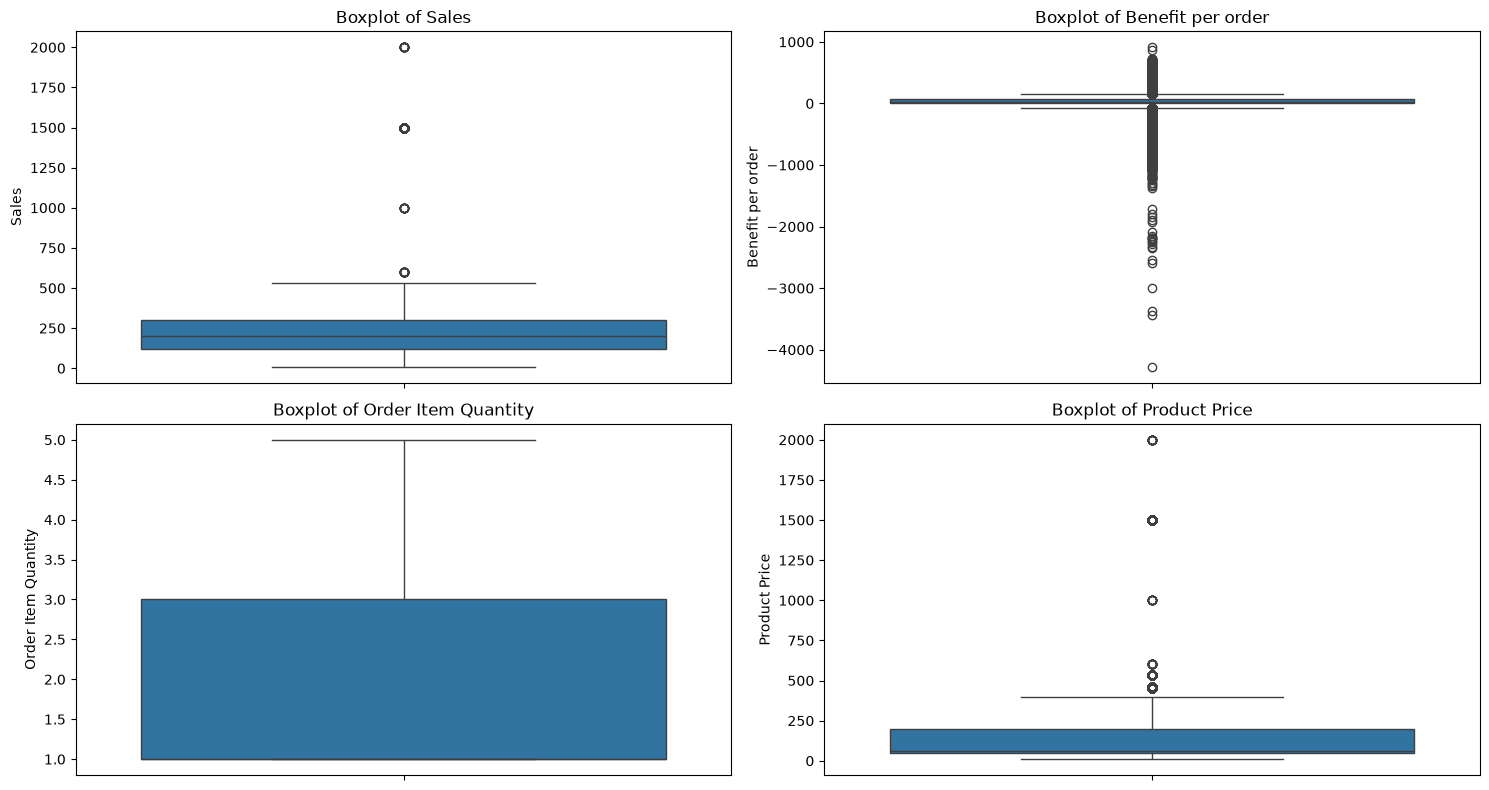

In [7]:
# 3.2. Phát hiện Outliers
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.3. Data Cleaning
Các bước thực hiện:
1. Xử lý giá trị trùng lặp (Duplicates).
2. Điền giá trị thiếu (Imputation) nếu có.
3. Mã hóa dữ liệu phân loại (Encoding Categorical Variables).

In [8]:
# 3.3. Data Cleaning
# 1. Loại bỏ các dòng trùng lặp
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Deleted {duplicate_count} duplicate row(s).")
else:
    print("No duplicate row.")

# 2. Xử lý missing values (nếu có)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Encoding (Cập nhật danh sách cột phân loại thực tế)
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Type', 'Delivery Status', 'Customer Segment', 'Market', 'Shipping Mode']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_Encoded'] = le.fit_transform(df[col])

# 4. Lưu dữ liệu sạch vào database
conn = sqlite3.connect('freight_pricing_research.db')
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
conn.close()

print("\n--- Cleaning successfully ---")

No duplicate row.

--- Cleaning successfully ---


### 3.4. EDA of Data Cleaning

**Correlation Matrix**

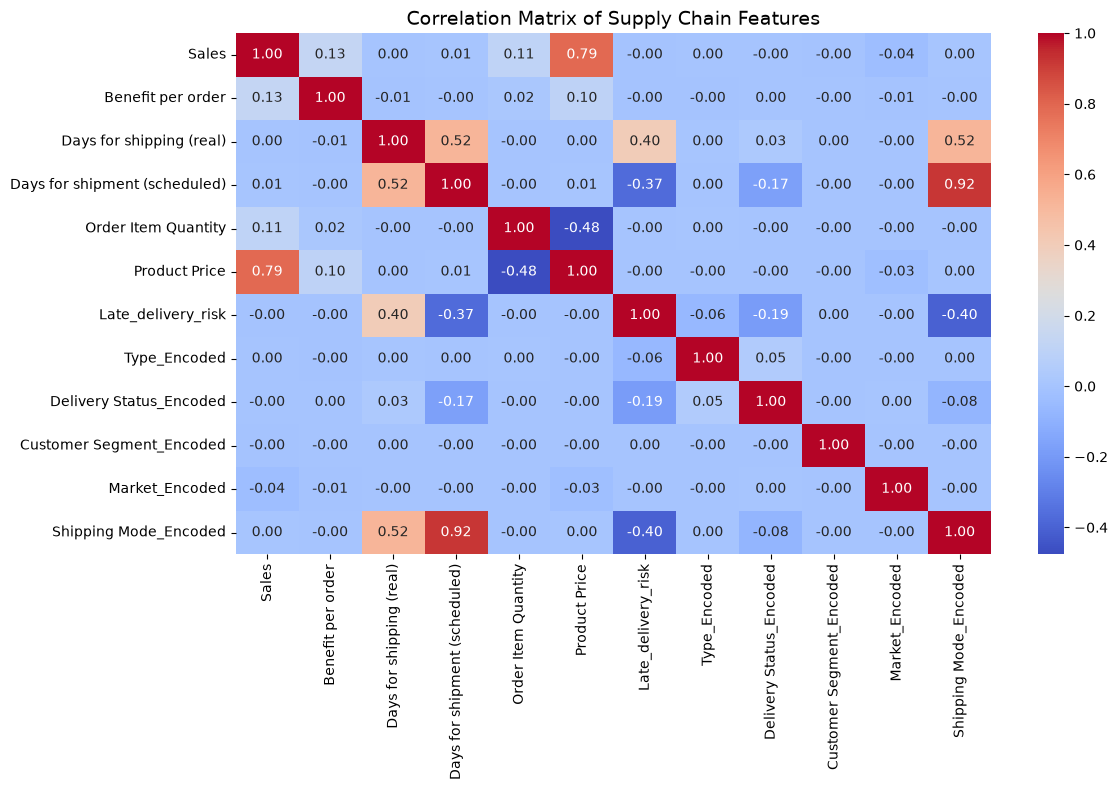

In [9]:
# Market Variables & Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Connect to the database and fetch clean data
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
cols_to_corr = [
    'Sales', 'Benefit per order', 'Days for shipping (real)', 
    'Days for shipment (scheduled)', 'Order Item Quantity', 
    'Product Price', 'Late_delivery_risk', 
    'Type_Encoded', 'Delivery Status_Encoded', 
    'Customer Segment_Encoded', 'Market_Encoded', 'Shipping Mode_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]

sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Supply Chain Features', fontsize=14)
plt.tight_layout()
plt.savefig('charts_img/34_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Outliers analysis**



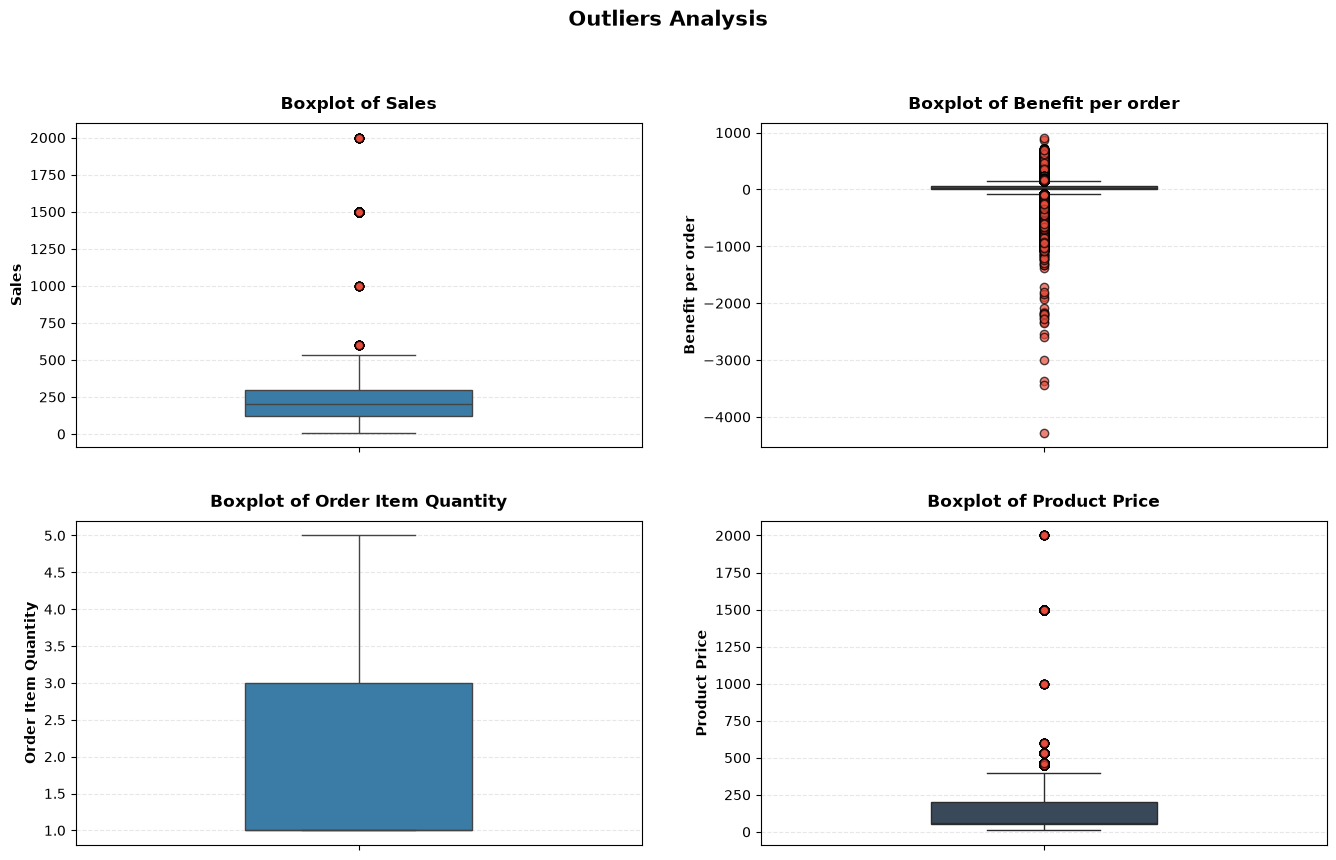

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Outliers Analysis', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('charts_img/34_outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. DATA VISUALIZATION


Trong mục này, nhóm sẽ thực hiện phân tích các RQ thoả mãn các mục title, axis labels, 1–2 Insight (nhận xét)

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*

### 4.1. [LINK TO RQ1] - Biểu đồ 1: Histogram - Khảo sát phân phối của biến chính (Sales)

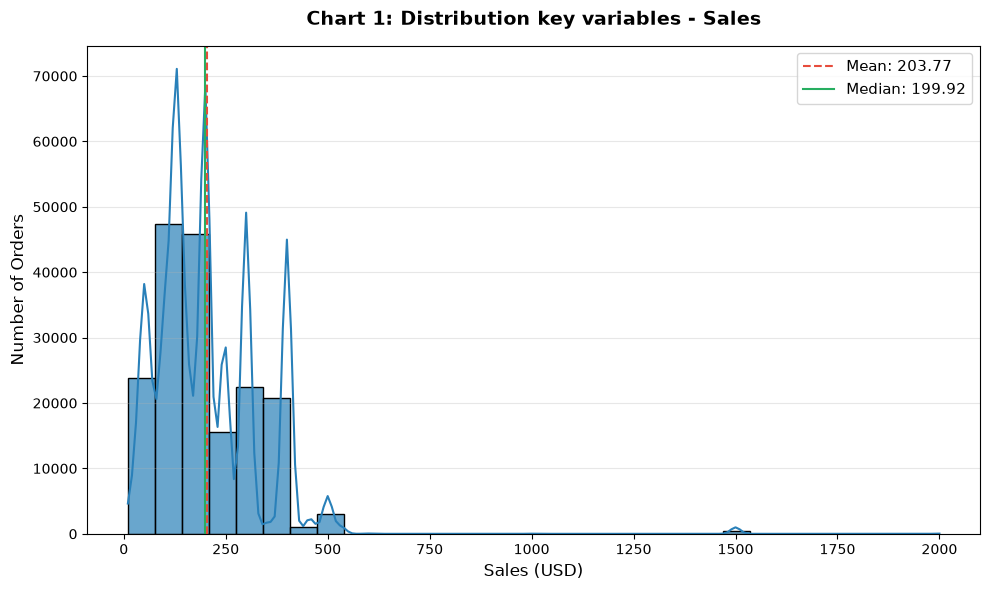

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd
import numpy as np

# 1. Kết nối database và lấy dữ liệu
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Vẽ biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=30, kde=True, color='#2980b9', edgecolor='black', alpha=0.7)

# 3. Thêm (Mean) và (Median) để làm rõ phân phối
mean_val = df['Sales'].mean()
median_val = df['Sales'].median()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#27ae60', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')

# 4. Title và axis labels
plt.title('Chart 1: Distribution key variables - Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sales (USD)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# 5. Thiết lập layout và lưu img
plt.tight_layout()
plt.savefig('charts_img/41_rq1_histogram_sales.png', dpi=300, bbox_inches='tight')
plt.show()

 **INSIGHT 1:** The transaction Sales primarily ranges from 9.99 to 2000 USD, with the average sales (Mean) reaching approximately 203.77 USD and the median reaching 199.92 USD.

**INSIGHT 2:** The distribution chart shows a strong right skewness, indicating that the majority of shipping orders represent low to medium transaction values, while high-value sales (> 1000 USD) account for a small proportion of overall orders.

### 4.2. [LINK TO RQ1] - Biểu đồ 2: Bar Chart - So sánh giá trị giữa các nhóm/phân loại.

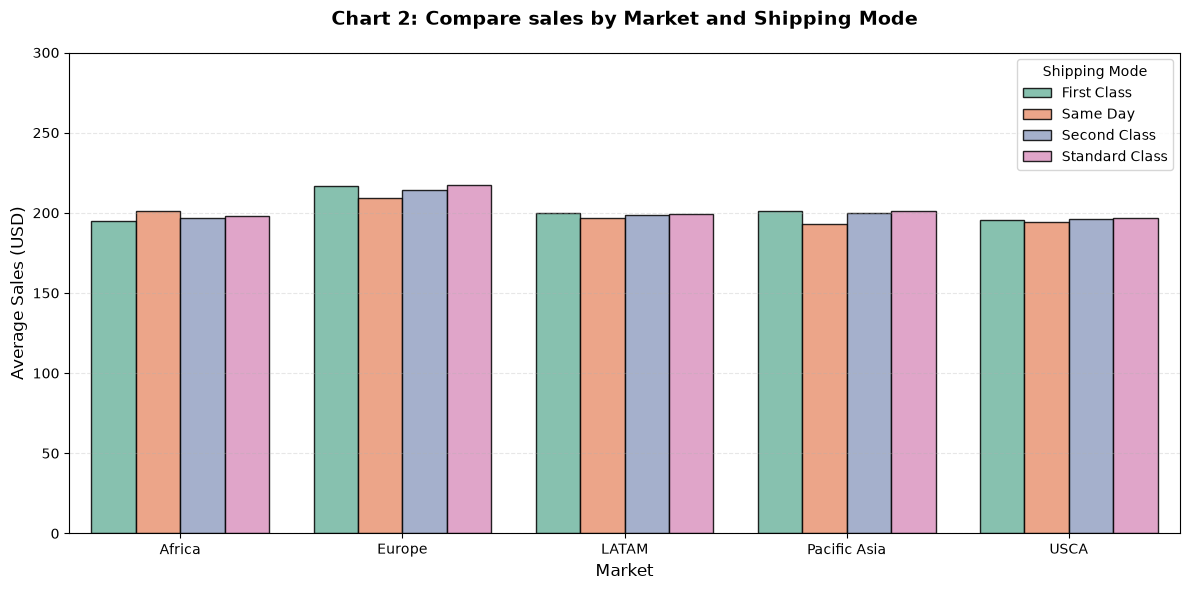

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Nhóm dữ liệu theo Market và Shipping Mode để tính trung bình Sales
grouped_df = df.groupby(['Market', 'Shipping Mode'])['Sales'].mean().reset_index()

# 3. Thiết lập kích thước biểu đồ và vẽ Bar Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Market',
    y='Sales',
    hue='Shipping Mode',
    data=grouped_df,
    palette='Set2',
    edgecolor='black',
    alpha=0.85
)

# 4. Thiết lập Title và Axis Labels
plt.title('Chart 2: Compare sales by Market and Shipping Mode', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Market', fontsize=12)
plt.ylabel('Average Sales (USD)', fontsize=12)
plt.ylim(0, 300)
plt.legend(title='Shipping Mode', fontsize=10, title_fontsize=10, loc='upper right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 5. Thiết lập layout và lưu img
plt.tight_layout()
plt.savefig('charts_img/42_rq1_bar_chart_sales.png', dpi=300, bbox_inches='tight')
plt.show()

**INSIGHT 1:** Europe consistently shows the highest average transaction sales across all shipping modes, exceeding 209 USD on average (with Standard Class peaking at 217.62 USD).

**INSIGHT 2:** Across all markets, standard and second-class shipping options hold similar or slightly higher average transaction values compared to premium fast options like Same Day, indicating that purchase volume or product value distribution dominates shipping mode selection.

### 4.3. [LINK TO RQ1] - Biểu đồ 3: Boxplot - Khảo sát phân bố và giá trị ngoại lai (outliers) của các biến chính.

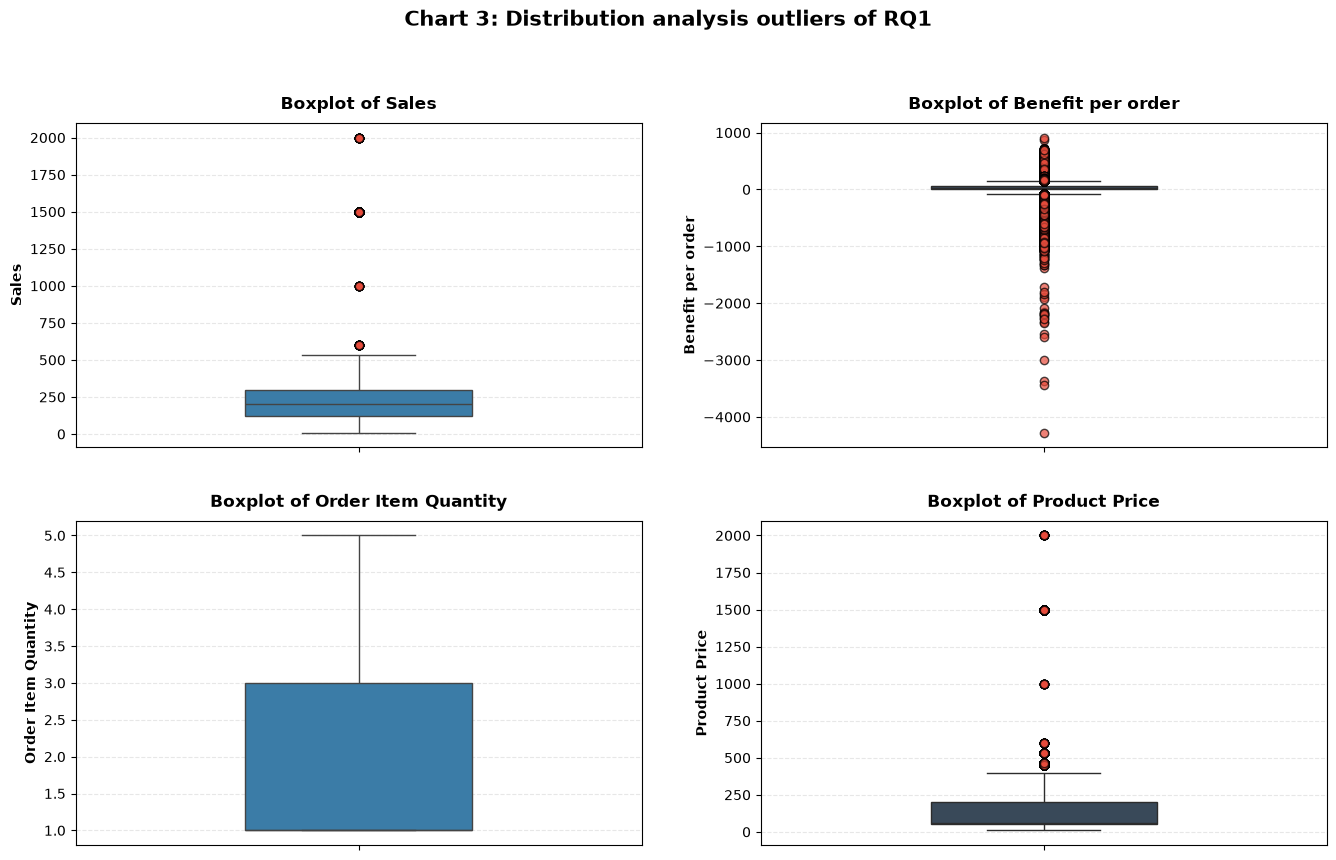

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Chart 3: Distribution analysis outliers of RQ1', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('charts_img/43_rq1_boxplot_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

**INSIGHT 1:** The `Sales` and `Product Price` features exhibit an even distribution with outliers concentrated in higher ranges (> 1000 USD), representing specialized high-end items.

**INSIGHT 2:** The `Benefit per order` boxplot shows significant outliers in both the positive and negative directions (extending below -4000 USD), representing severe operational shipping losses or high penalty costs.

### 4.4. [LINK TO RQ2] - Biểu đồ 4: Scatter Plot - Khảo sát mối tương quan giữa hai biến liên tục.

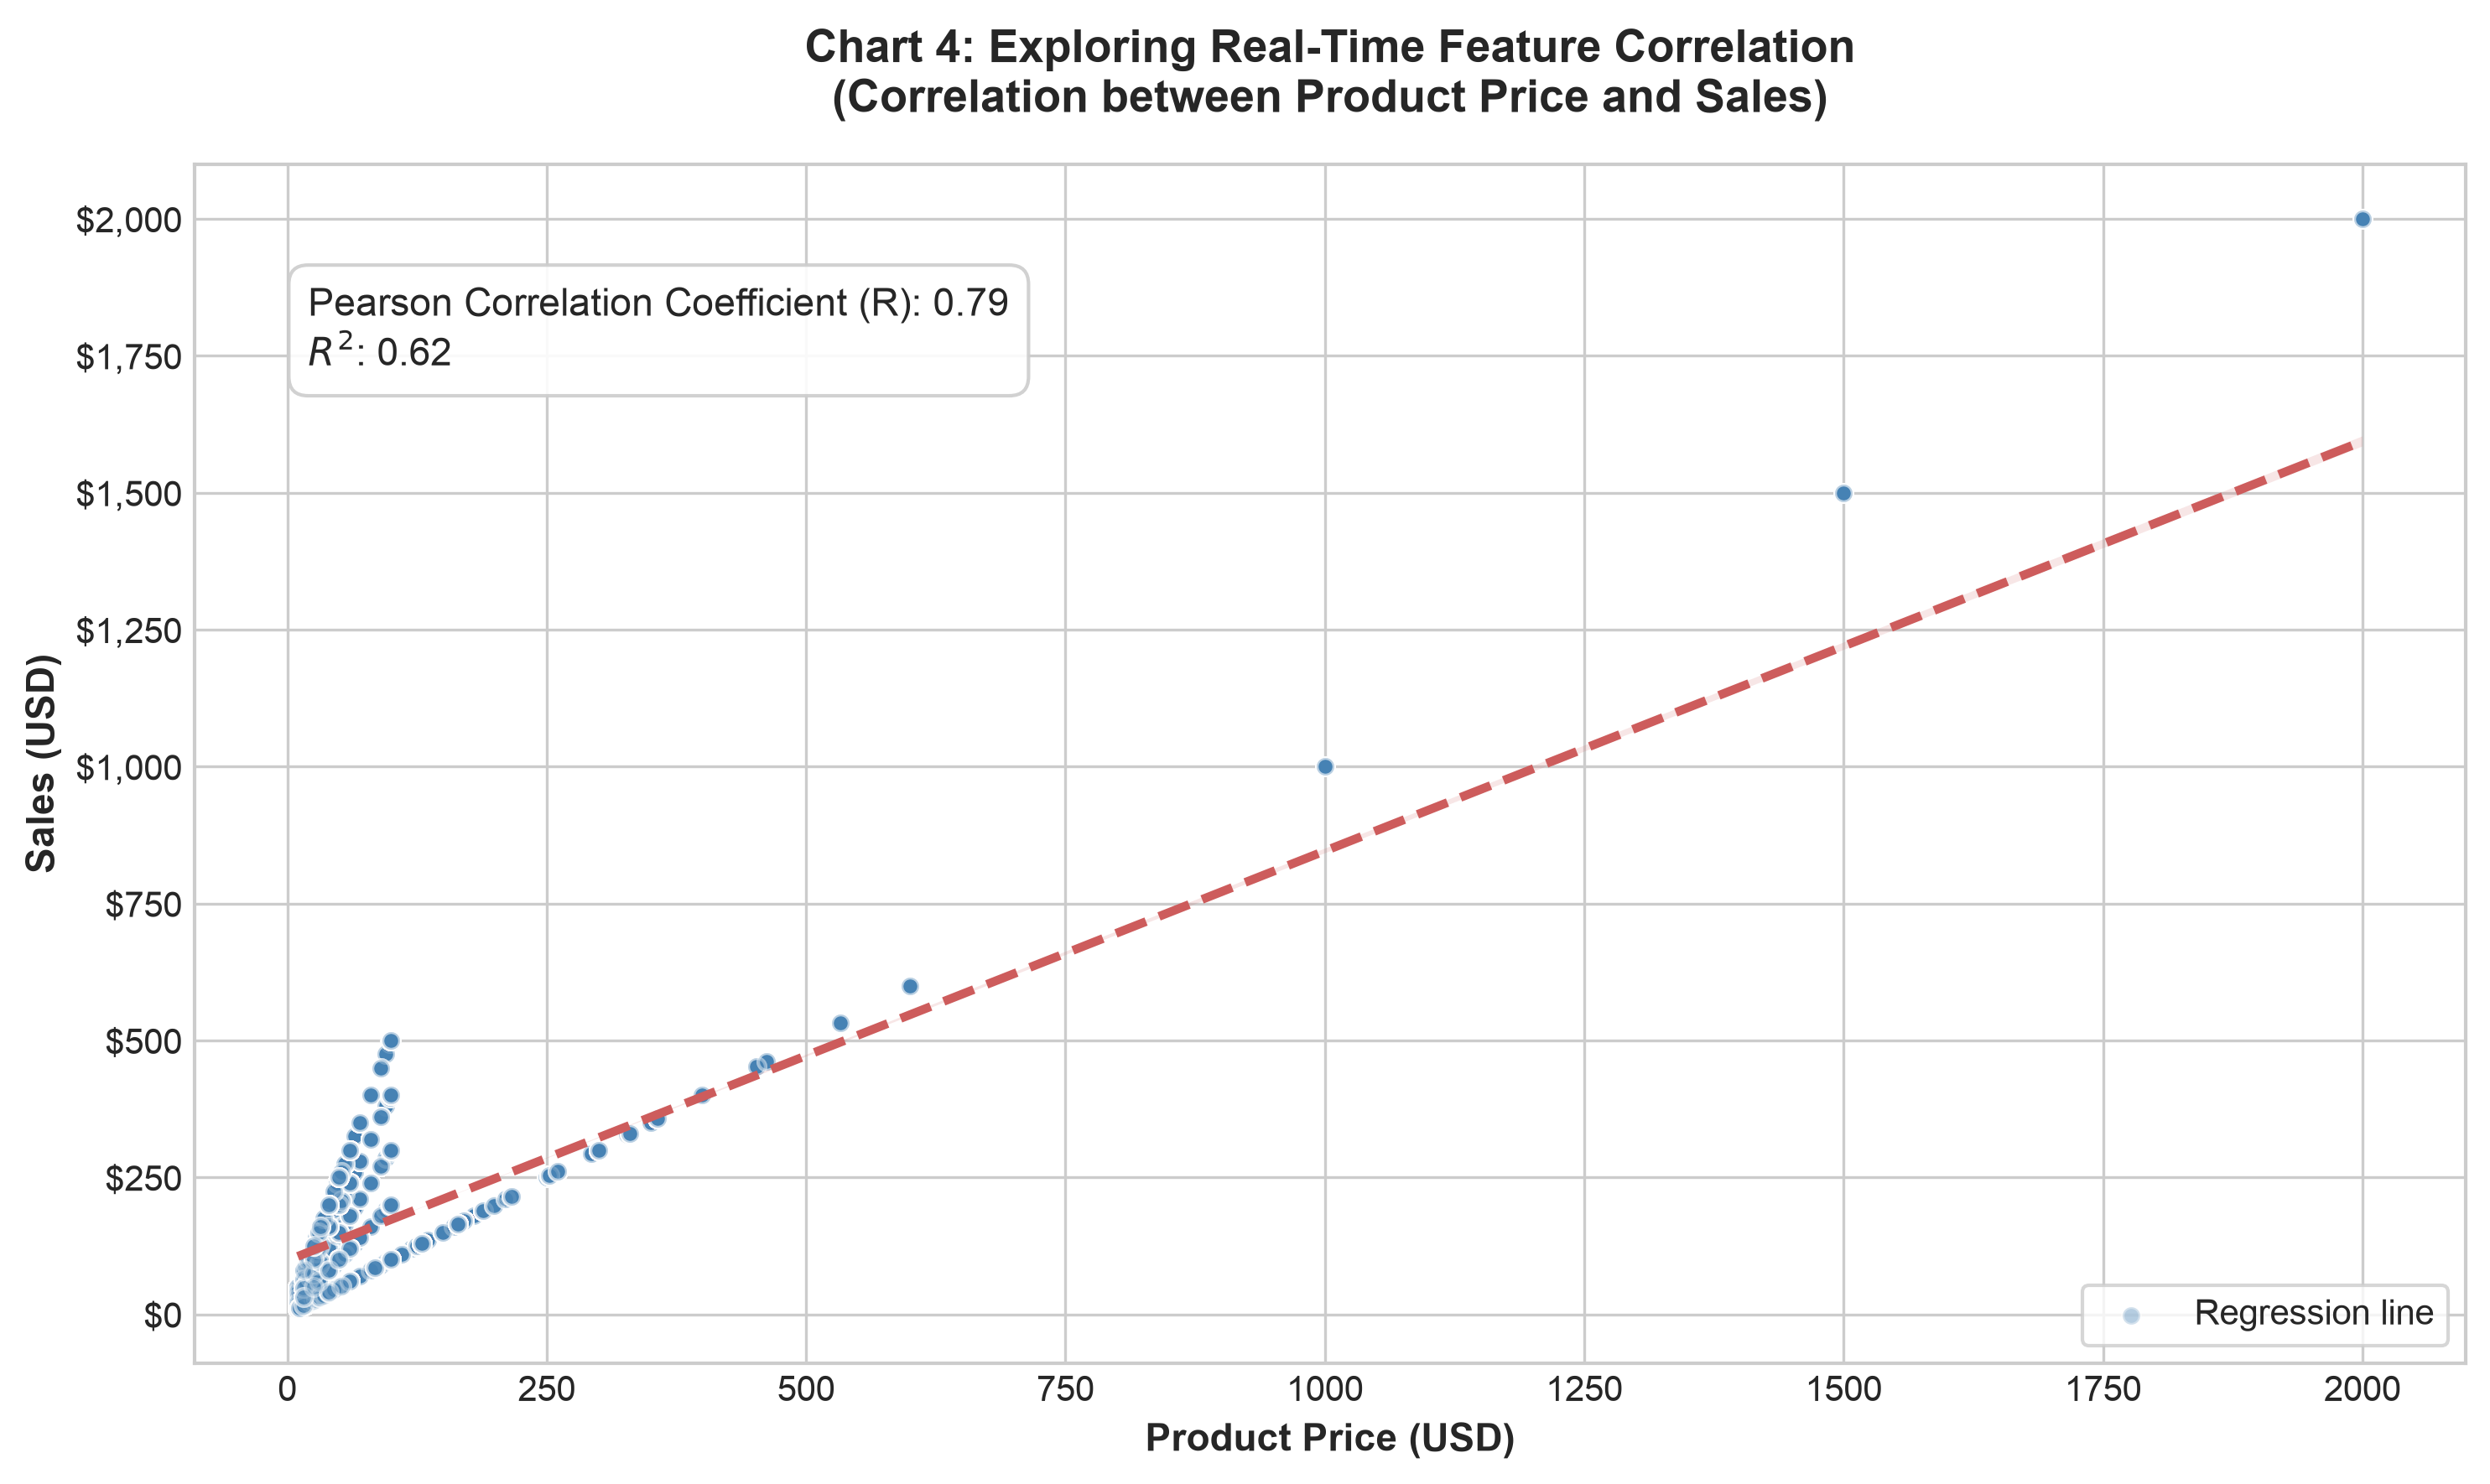

In [14]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Định nghĩa các biến số học cho biểu đồ
x_var = "Product Price"
y_var = "Sales"

# Khởi tạo khung vẽ biểu đồ với độ phân giải cao
plt.figure(figsize=(10, 6), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# 3. Tính toán các chỉ số thống kê học thuật (Pearson R & R-squared)
r_value, _ = pearsonr(df[x_var], df[y_var])
r_squared = r_value**2

# 4. Vẽ các điểm dữ liệu (Scatter Plot) và đường hồi quy (Regression Line)
sns.regplot(
    data=df,
    x=x_var,
    y=y_var,
    scatter_kws={"alpha": 0.4, "color": "#4682B4", "edgecolors": "w", "s": 25},
    line_kws={"color": "#CD5C5C", "linestyle": "--", "linewidth": 2.5},
    label="Regression line",
)

# 5. Chèn hộp thông tin chỉ số thống kê toán học lên góc trên bên trái biểu đồ
stats_text = f"Pearson Correlation Coefficient (R): {r_value:.2f}\n$R^2$: {r_squared:.2f}"
plt.gca().text(
    0.05,
    0.90,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="0.8", alpha=0.9),
)

# 6. Cấu hình tiêu đề và nhãn trục
plt.title(
    "Chart 4: Exploring Real-Time Feature Correlation\n(Correlation between Product Price and Sales)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Price (USD)", fontsize=11, fontweight="bold")
plt.ylabel("Sales (USD)", fontsize=11, fontweight="bold")

# Định dạng hiển thị tiền tệ ($) trên trục tung cho chuyên nghiệp
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))

# Thêm chú thích (Legend) và tối ưu bố cục khoảng cách biên
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

# 7. Lưu biểu đồ ra file ảnh chất lượng cao
plt.savefig("charts_img/44_rq2_scatter_plot_correlation.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** A Pearson correlation coefficient of 0.79 confirms that `Product Price` is the dominant factor driving the final transactional `Sales` value. However, the dispersion of points around the regression line suggests that transaction modifiers, such as bulk quantity orders and discount schemes, introduce substantial variance, indicating that simple linear methods are insufficient and machine learning estimators will yield superior performance.

### 4.5. [LINK TO RQ2] - Biểu đồ 5: Heatmap Correlation  - Bản đồ nhiệt thể hiện ma trận tương quan giữa các thuộc tính.

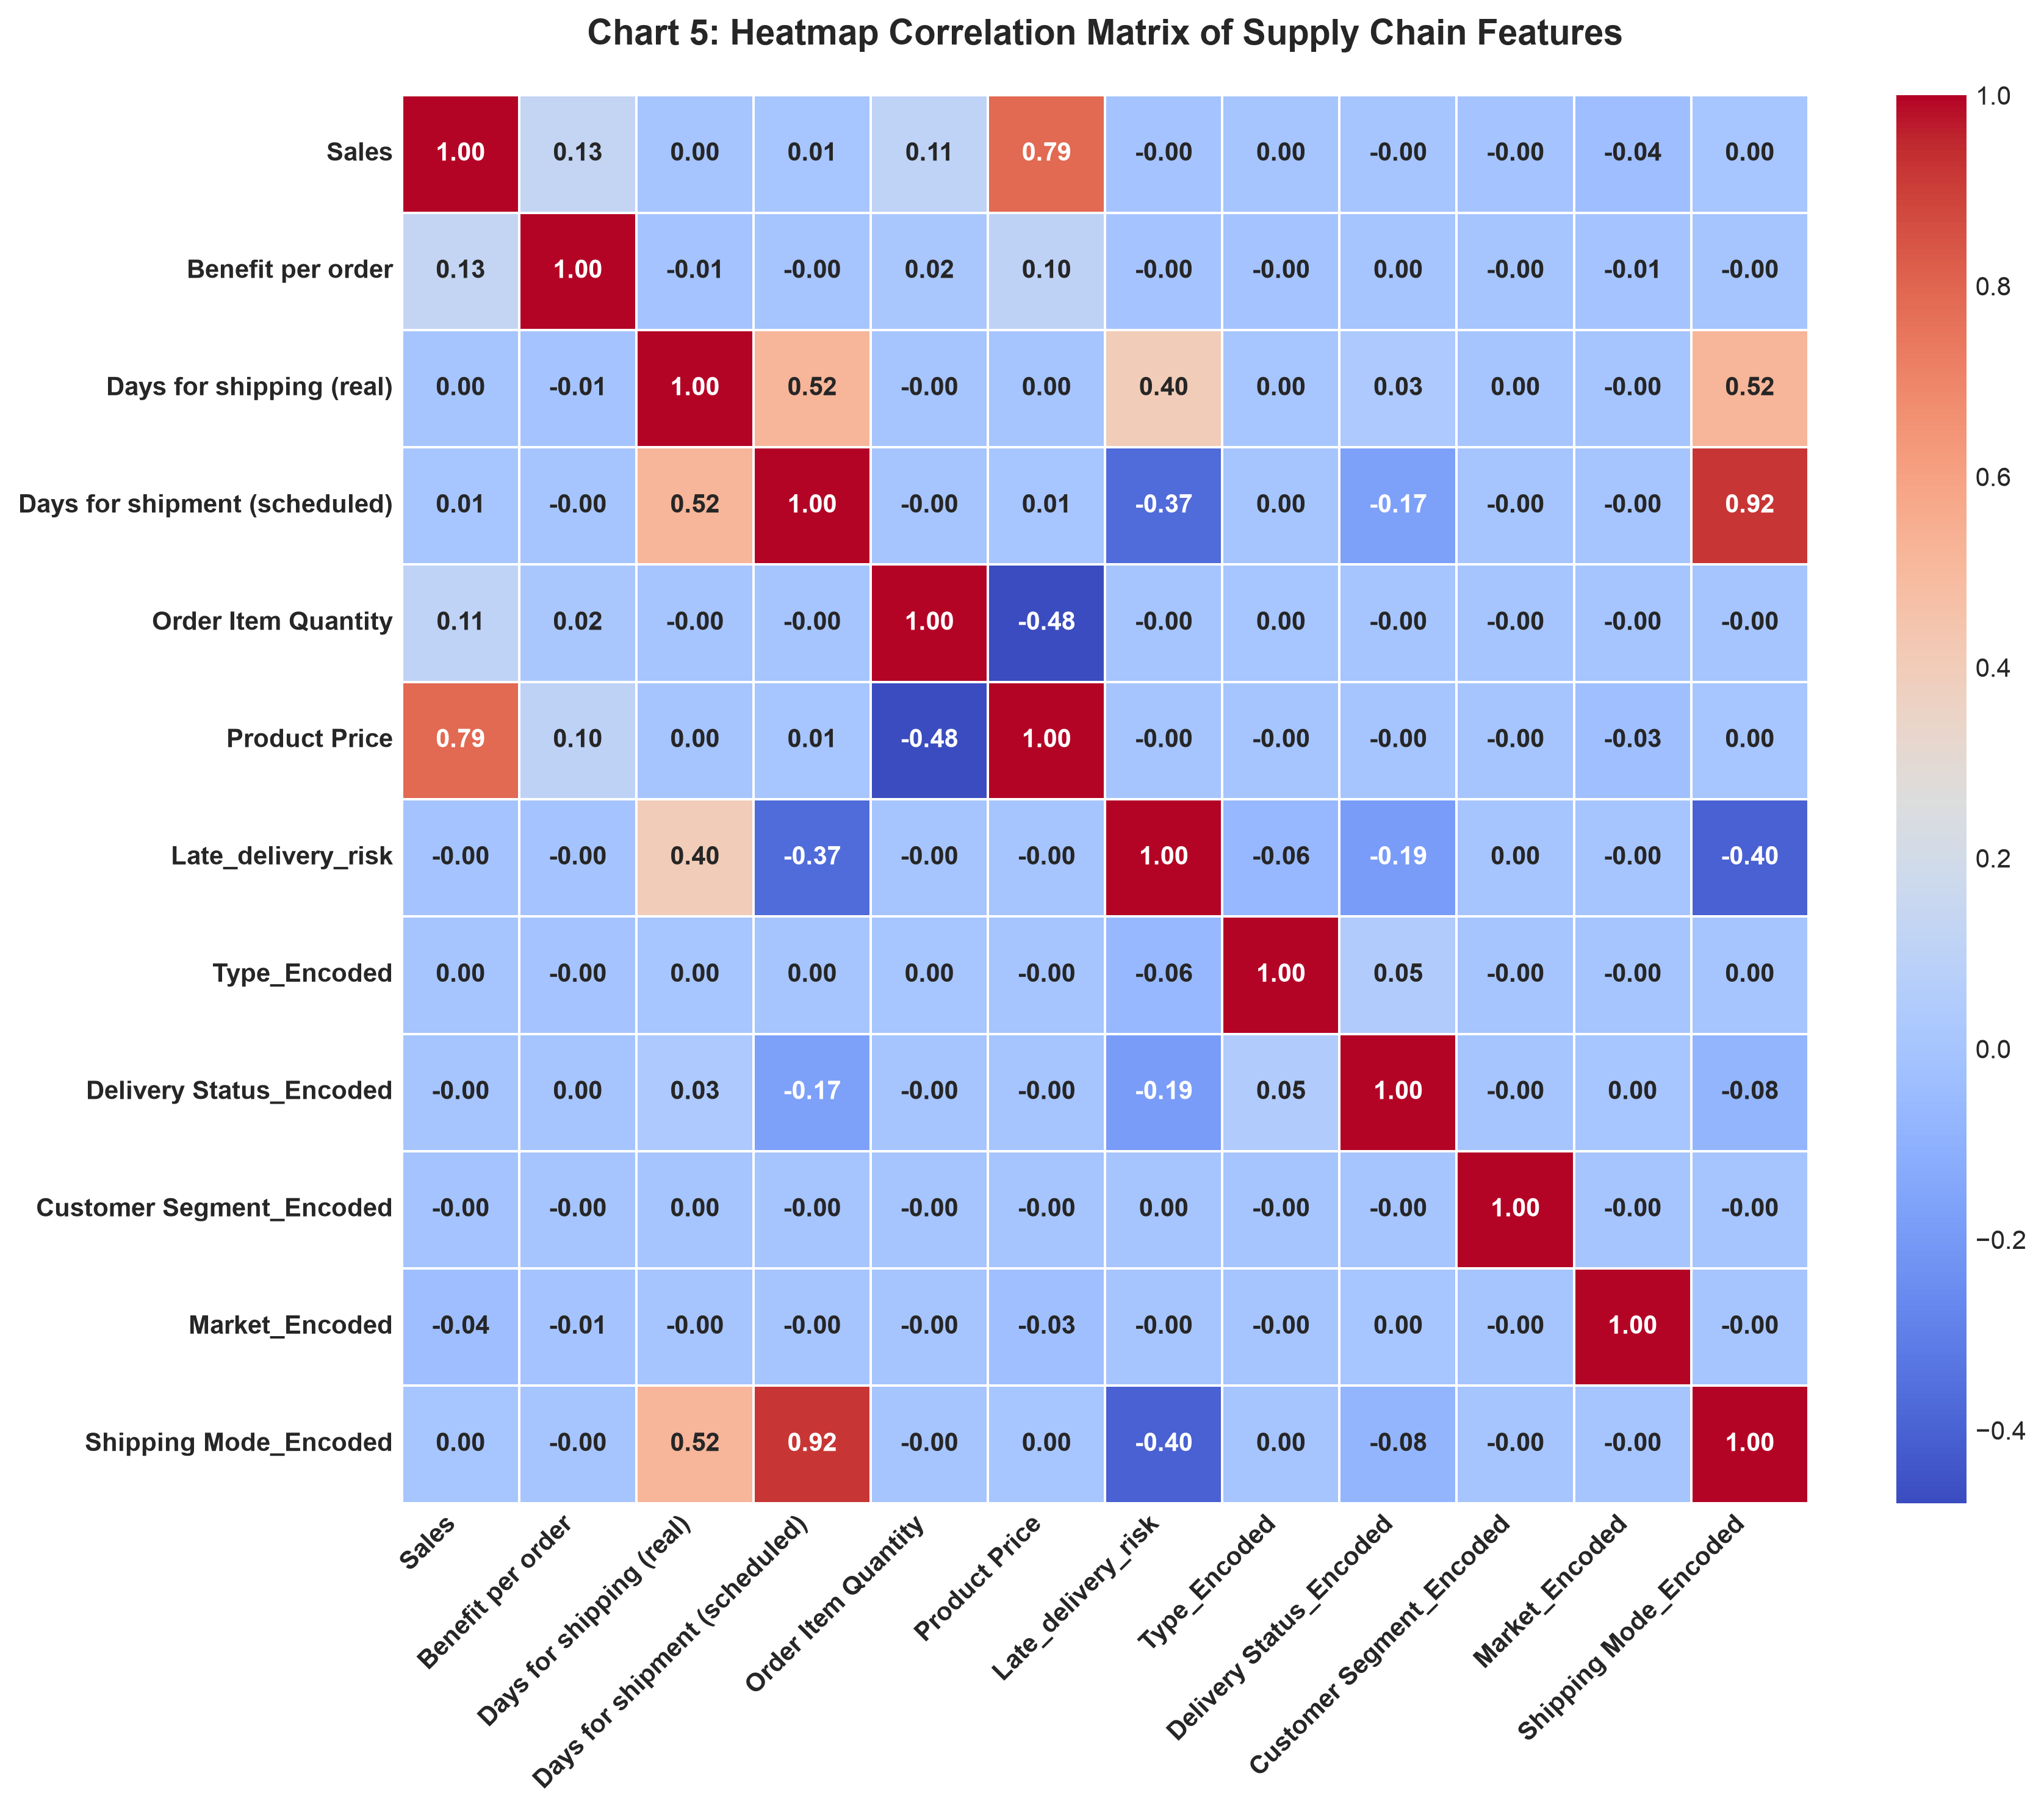

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Tính toán ma trận tương quan (Chỉ tính trên cột số quan trọng)
cols_to_corr = [
    'Sales', 'Benefit per order', 'Days for shipping (real)', 
    'Days for shipment (scheduled)', 'Order Item Quantity', 
    'Product Price', 'Late_delivery_risk', 
    'Type_Encoded', 'Delivery Status_Encoded', 
    'Customer Segment_Encoded', 'Market_Encoded', 'Shipping Mode_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]
corr_matrix = df[cols_to_corr].corr()

# 3. Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(12, 10), dpi=300)

# 4. Vẽ bản đồ nhiệt Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"},
)

# 5. Cấu hình tiêu đề chuẩn hóa
plt.title(
    "Chart 5: Heatmap Correlation Matrix of Supply Chain Features",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight="bold")
plt.yticks(rotation=0, fontsize=10, fontweight="bold")

# 6. Hiển thị biểu đồ
plt.tight_layout()
plt.savefig("charts_img/45_rq2_heatmap_correlation_matrix.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The empirical correlation matrix confirms that `Product Price` has the strongest positive linear relationship with `Sales` at 0.79, followed by `Order Item Quantity`. Delivery metrics like `Days for shipping (real)` and `Days for shipment (scheduled)` show weak correlation with transactional sales, suggesting logistics timelines operate independently of product value.

### 4.6. [LINK TO RQ2] - Biểu đồ 6: Line Chart - Biểu thị xu hướng thay đổi hoặc biến thiên của dữ liệu theo chuỗi.

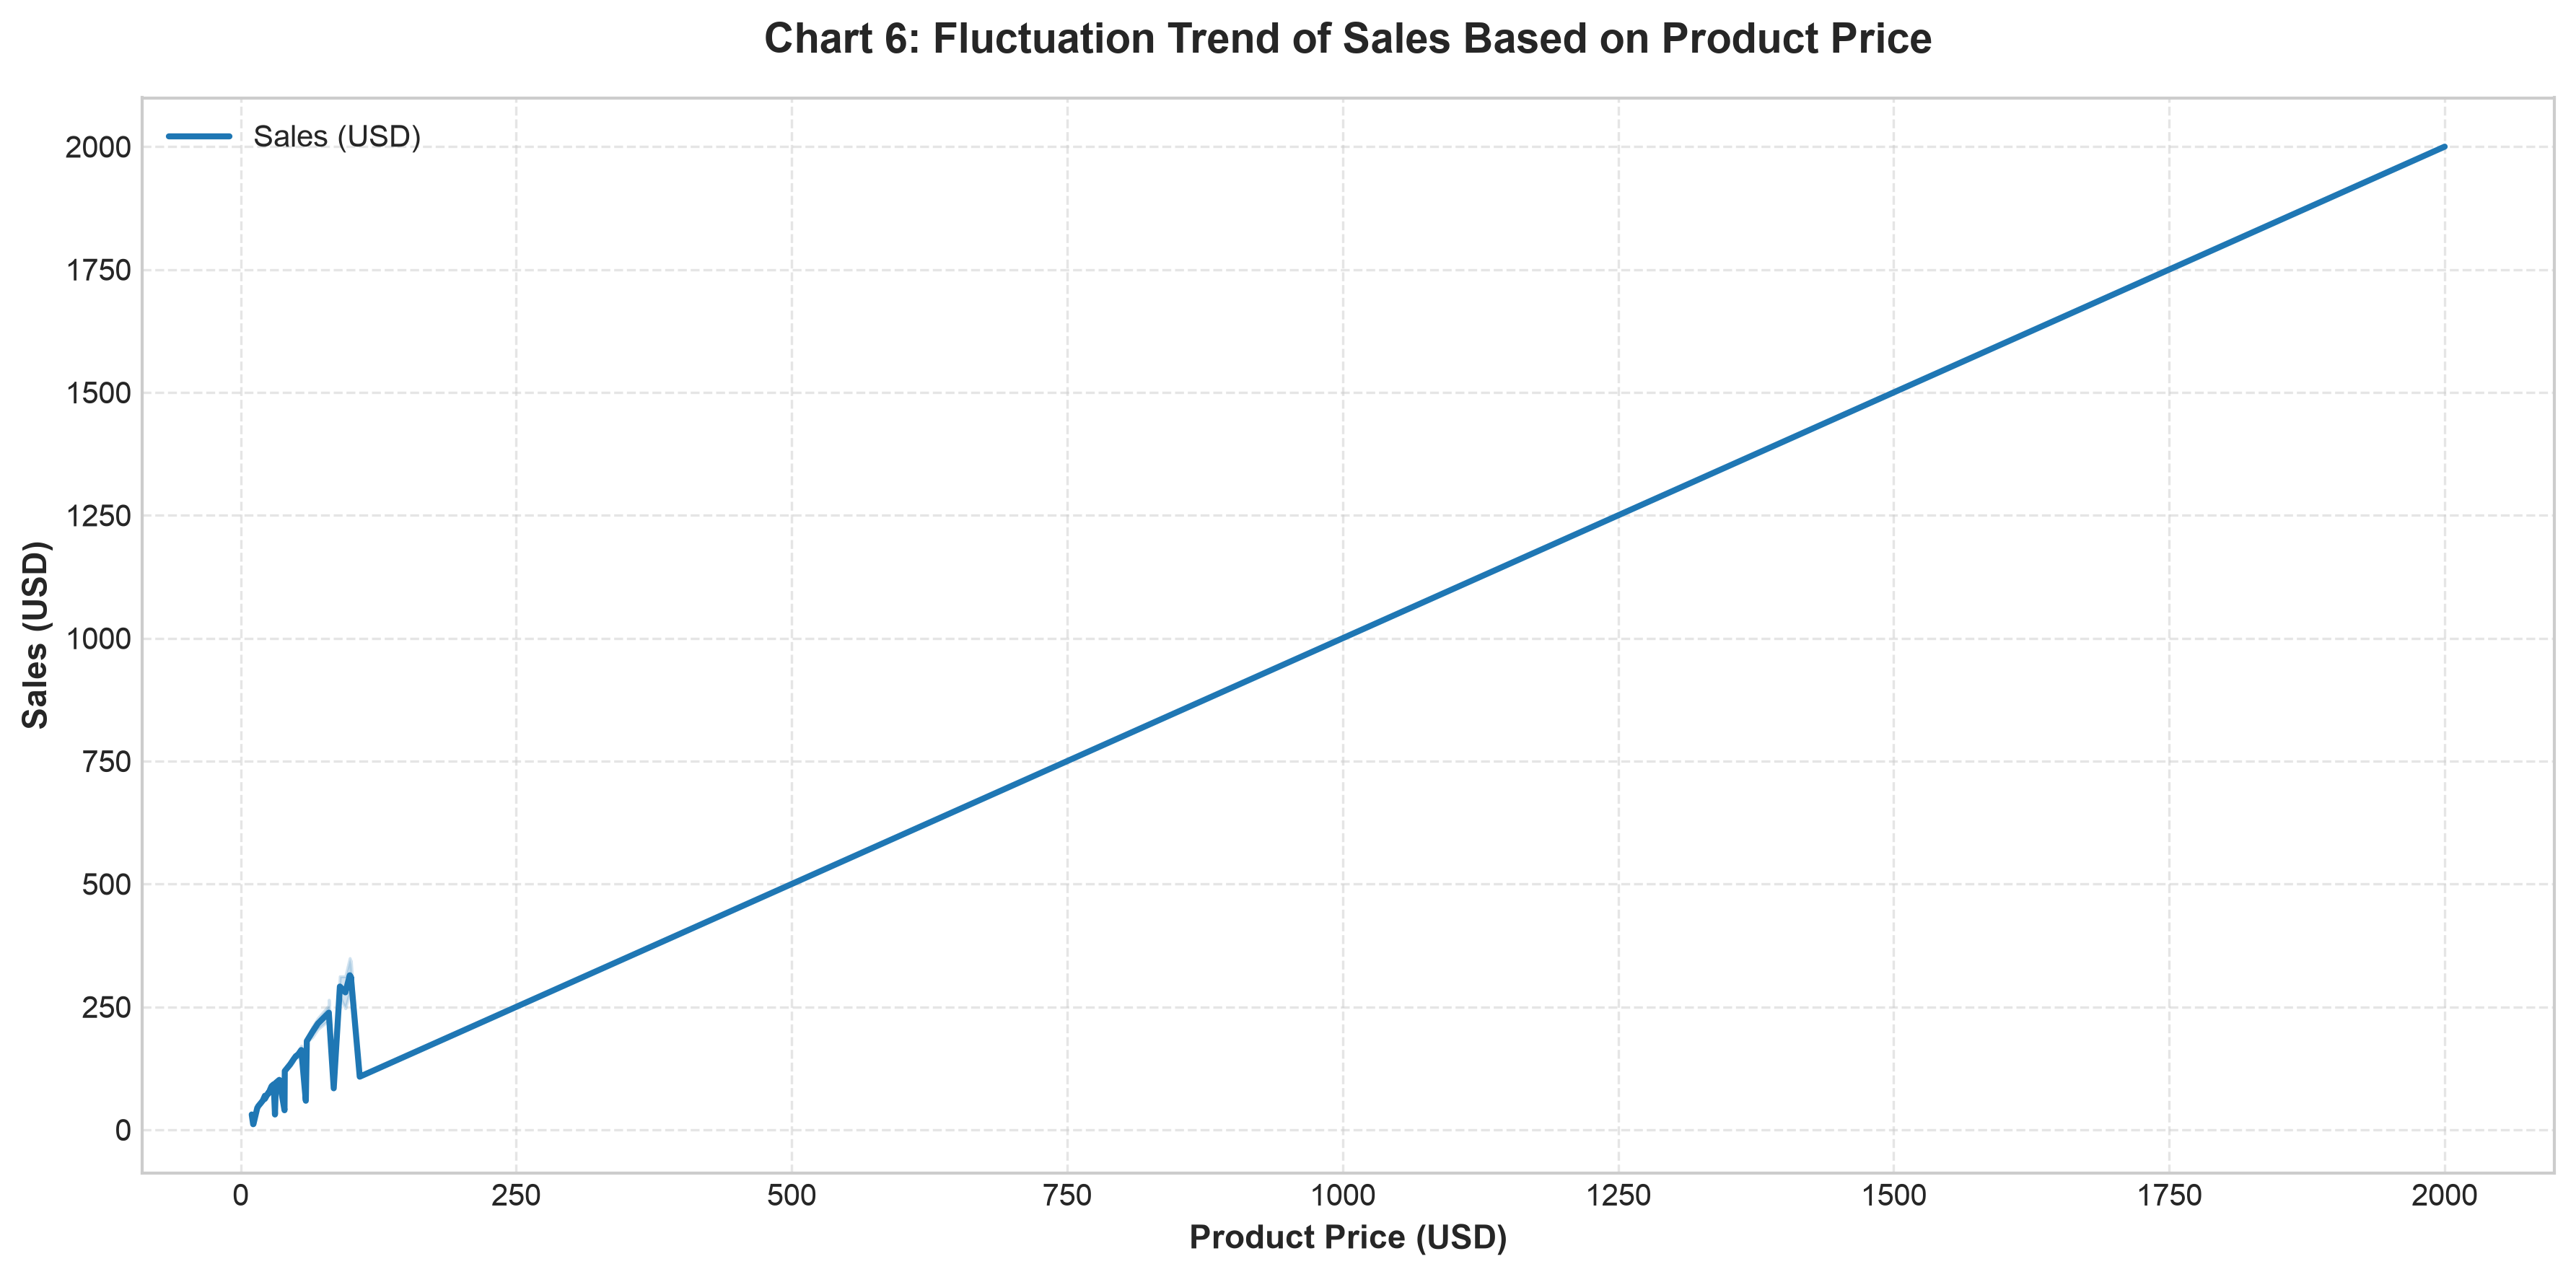

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(12, 6), dpi=300)

# 3. Vẽ biểu đồ đường (Line Chart)
sns.lineplot(
    data=df,
    x="Product Price",
    y="Sales",
    color="#1f77b4",
    linewidth=2,
    label="Sales (USD)",
)

# 4. Cấu hình tiêu đề và nhãn
plt.title(
    "Chart 6: Fluctuation Trend of Sales Based on Product Price",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Price (USD)", fontsize=11, fontweight="bold")
plt.ylabel("Sales (USD)", fontsize=11, fontweight="bold")

# 5. Thêm lưới nền
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

# 6. Tối ưu khoảng cách và hiển thị
plt.tight_layout()
plt.savefig("charts_img/46_rq2_line_chart_fluctuation_trend.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The Line Chart depicts a clear positive progression of sales values corresponding to increases in product price, mirroring the correlation results. The high frequency fluctuations reflect different discount percentages and bulk quantities associated with specific product price points.

### 4.7. [LINK TO RQ3] - Biểu đồ 7: Bar Chart - Khảo sát phân bố số lượng đơn hàng theo khu vực (Market)

/var/folders/40/w0zgy5_j6r3db9sp7kx1l6w00000gn/T/ipykernel_1863/1367129147.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


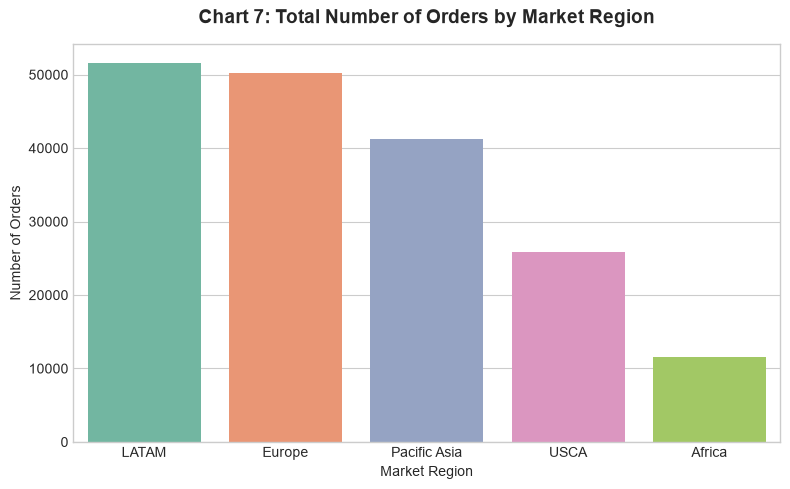

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

conn = sqlite3.connect('freight_pricing_research.db')

df_region = pd.read_sql_query("""
SELECT
    Market,
    COUNT(*) AS Total_Rides
FROM supply_chain
GROUP BY Market
ORDER BY Total_Rides DESC
""", conn)

conn.close()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_region,
    x='Market',
    y='Total_Rides',
    palette='Set2'
)
plt.title(
    'Chart 7: Total Number of Orders by Market Region',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Market Region')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.savefig("charts_img/47_rq3_bar_chart_total_number_of_rides.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** Latin America (LATAM) and Europe are the largest market segments, contributing significantly higher numbers of orders compared to the other regions.

**INSIGHT 2:** Order density is heavily skewed towards LATAM, Europe, and Pacific Asia, which accounts for the vast majority of the supply chain transaction logs, leaving USCA and Africa as smaller segments.

### 4.8. [LINK TO RQ3] - Biểu đồ 8: Boxplot - Distribution of Sales by Shipping Mode

/var/folders/40/w0zgy5_j6r3db9sp7kx1l6w00000gn/T/ipykernel_1863/1209867125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


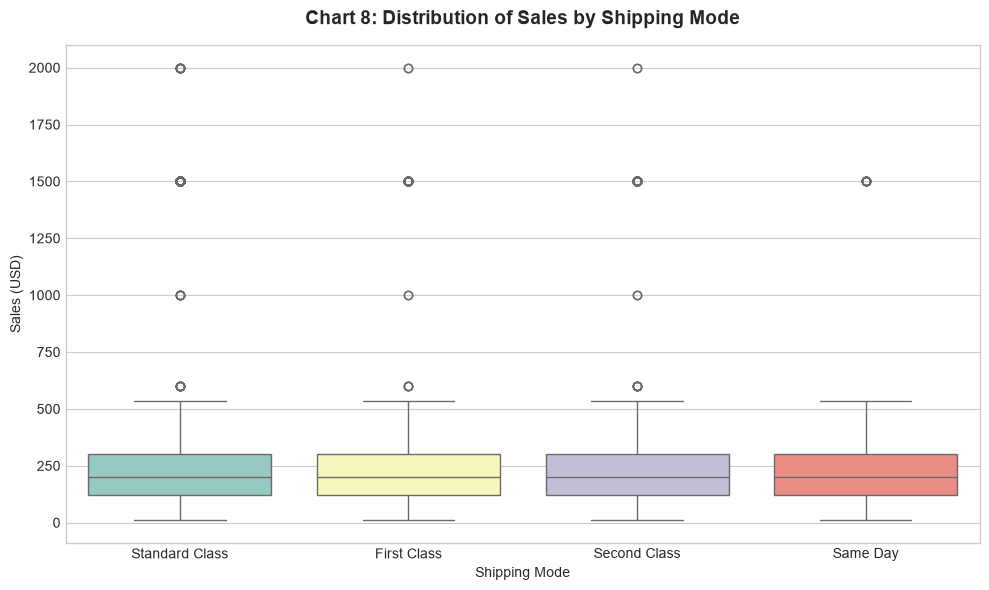

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Shipping Mode',
    y='Sales',
    palette='Set3'
)
plt.title(
    'Chart 8: Distribution of Sales by Shipping Mode',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Shipping Mode')
plt.ylabel('Sales (USD)')

plt.tight_layout()
plt.savefig("charts_img/48_rq3_boxplot_distribution_of_historical_cost.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The median, lower quartile, and upper quartile of sales remain consistently stable across all shipping modes, showing no major price bias based on shipping options.

**INSIGHT 2:** All shipping classes feature high-value outlier transactions exceeding 1000 USD, suggesting expensive shipments are distributed uniformly across different priority classes.

### 4.9. [LINK TO RQ3] - Biểu đồ 9: Stacked Bar Chart - Shipping Mode Composition by Customer Segment

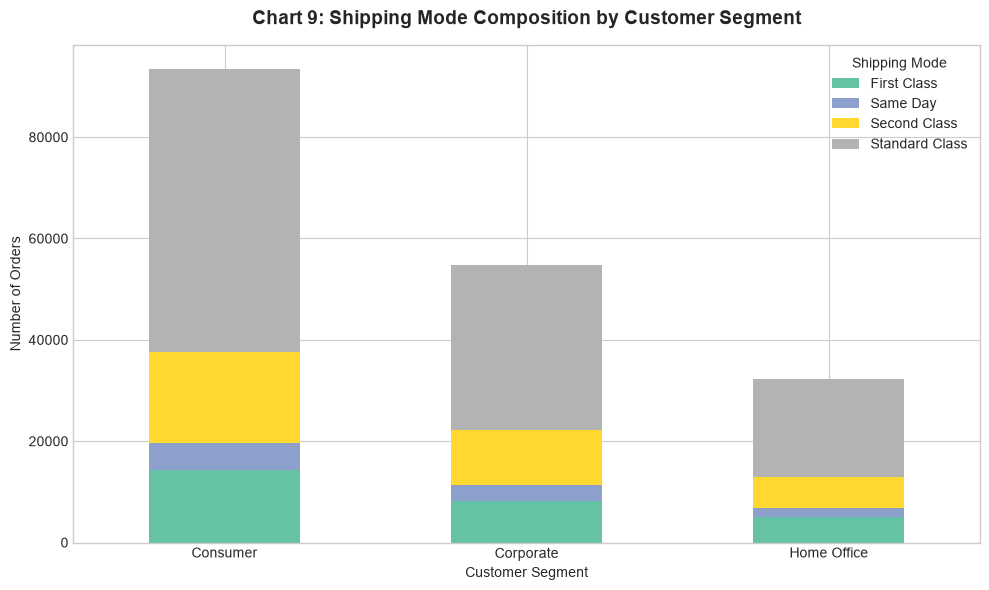

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

stacked_data = pd.crosstab(
    df['Customer Segment'],
    df['Shipping Mode']
)

stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set2'
)
plt.title(
    'Chart 9: Shipping Mode Composition by Customer Segment',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Orders')

plt.legend(title='Shipping Mode')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts_img/49_rq3_stacked_bar_chart_vehicle_type_composition.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The consumer segment yields the largest overall number of orders, followed by Corporate and Home Office segments.

**INSIGHT 2:** The proportion of shipping modes is highly consistent across all customer segments, with Standard Class being the dominant shipping option chosen by all types of buyers.

### 4.10. Biểu đồ 10: Distribution of Shipping Modes

/var/folders/40/w0zgy5_j6r3db9sp7kx1l6w00000gn/T/ipykernel_1863/1812814132.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


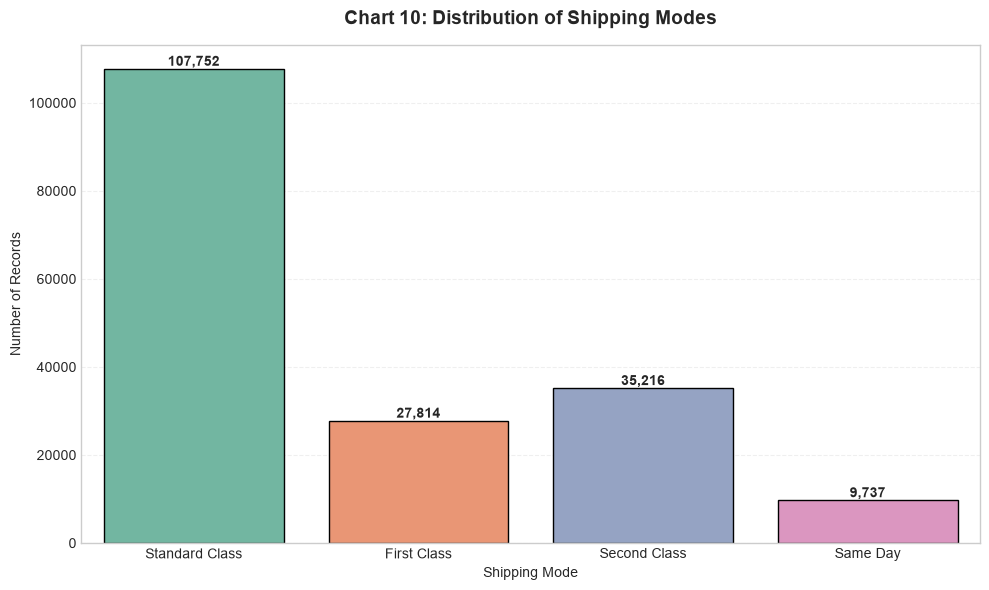

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Kết nối database
conn = sqlite3.connect("freight_pricing_research.db")
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# Thiết lập kích thước
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="Shipping Mode",
    palette="Set2",
    edgecolor="black"
)

# Hiển thị số lượng trên từng cột
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Chart 10: Distribution of Shipping Modes",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Shipping Mode")
plt.ylabel("Number of Records")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "charts_img/410_vehicle_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**INSIGHT 1:** Standard Class shipping is the most widely used shipping mode (107,752 records), representing the baseline delivery class, whereas Same Day (9,737 records) represents the high-priority premium logistics option.

**INSIGHT 2:** Understanding the distribution of shipping modes provides essential parameters for the dynamic pricing optimizer to scale pricing premiums correctly based on baseline priority capacity vs rush orders.

## 5. Feature Engineering

### 5.1. FEATURE 1: Tổng nhu cầu (Demand) theo ngày đặt hàng

In [28]:
import pandas as pd

# 1. Đọc file dữ liệu gốc
# Sử dụng encoding 'latin1' cho DataCoSupplyChainDataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

# 2. Xử lý ngày tháng và tính tổng nhu cầu (Order Item Quantity) theo ngày
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['Order_Date_Only'] = df['order date (DateOrders)'].dt.date
daily_demand = df.groupby('Order_Date_Only')['Order Item Quantity'].sum().reset_index()
daily_demand.rename(columns={'Order Item Quantity': 'Daily_Demand'}, inplace=True)

# Merge lại vào dataframe gốc
df = df.merge(daily_demand, on='Order_Date_Only', how='left')

# 3. Lưu và kiểm tra kết quả
df.to_csv('features.csv', index=False) # dùng file này để train model cho các Feature tiếp theo
print('Feature 1: Daily_Demand')
print(df[['Order_Date_Only', 'Order Item Quantity', 'Daily_Demand']].head())


Feature 1: Daily_Demand
  Order_Date_Only  Order Item Quantity  Daily_Demand
0      2018-01-31                    1            68
1      2018-01-13                    1            68
2      2018-01-13                    1            68
3      2018-01-13                    1            68
4      2018-01-13                    1            68


### 5.2. FEATURE 2: Xác định giờ cao điểm (Is_Peak_Hour)

Trích giờ đặt hàng từ cột `order date (DateOrders)` trong DataCoSupplyChainDataset.

- **Giờ cao điểm** (8h - 17h): `Is_Peak_Hour = 1`
- **Ngoài giờ cao điểm**: `Is_Peak_Hour = 0`

In [29]:
import pandas as pd

# 1. Đọc file dữ liệu (Đọc từ file đã chạy ở bước 1 để giữ lại biến trước)
df = pd.read_csv("features.csv")

# 2. Trích giờ đặt hàng từ cột 'order date (DateOrders)' và xác định giờ cao điểm
# Giờ cao điểm kinh doanh: 8h-17h (Morning + Afternoon)
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['Order_Hour'] = df['order date (DateOrders)'].dt.hour
df['Is_Peak_Hour'] = df['Order_Hour'].apply(lambda h: 1 if 8 <= h <= 17 else 0)

# 3. Lưu và kiểm tra kết quả
df.to_csv("features.csv", index=False)
print("Feature 2: Is_Peak_Hour")
print("Total of Is_Peak_Hour rows:", df["Is_Peak_Hour"].sum())
print(df[["Order_Hour", "Is_Peak_Hour"]].head())

Feature 2: Is_Peak_Hour
Total of Is_Peak_Hour rows: 75300
   Order_Hour  Is_Peak_Hour
0          22             0
1          12             1
2          12             1
3          11             1
4          11             1


### 5.3. FEATURE 3: Mức độ nhu cầu khẩn cấp (Demand_Urgency)

Kết hợp 3 yếu tố từ DataCoSupplyChainDataset:
- `Is_Peak_Hour`: Giờ cao điểm (Feature 2)
- `Shipping Mode`: Phương thức vận chuyển nhanh (Same Day / First Class)
- `Late_delivery_risk`: Rủi ro giao trễ

In [31]:
import pandas as pd

# 1. Đọc file dữ liệu (Đọc từ file đã chứa Feature 1 và Feature 2)
df = pd.read_csv("features.csv")

# 2. Xác định Demand_Urgency: kết hợp giờ cao điểm + phương thức vận chuyển nhanh + rủi ro giao trễ
# Logic: Đơn hàng trong giờ cao điểm, chọn giao nhanh (Same Day / First Class),
# và có rủi ro giao trễ -> mức độ khẩn cấp cao
df['Demand_Urgency'] = df.apply(
    lambda row: 1
    if (row['Is_Peak_Hour'] == 1
        and row['Shipping Mode'] in ['Same Day', 'First Class']
        and row['Late_delivery_risk'] == 1)
    else 0,
    axis=1,
)

# 3. Lưu file sạch cuối cùng để huấn luyện mô hình AI
df.to_csv("features.csv", index=False)
print("Feature 3: Demand_Urgency")
print("Total of Demand_Urgency rows:", df["Demand_Urgency"].sum())
print(df[["Is_Peak_Hour", "Shipping Mode", "Late_delivery_risk", "Demand_Urgency"]].head(10))

Feature 3: Demand_Urgency
Total of Demand_Urgency rows: 13475
   Is_Peak_Hour   Shipping Mode  Late_delivery_risk  Demand_Urgency
0             0  Standard Class                   0               0
1             1  Standard Class                   1               0
2             1  Standard Class                   0               0
3             1  Standard Class                   0               0
4             1  Standard Class                   0               0
5             1  Standard Class                   0               0
6             1     First Class                   1               1
7             1     First Class                   1               1
8             1    Second Class                   1               0
9             1     First Class                   1               1


### 5.4. Feature 4: Phân loại khách hàng (Customer_Segment_Encoded)

Sử dụng cột `Customer Segment` có sẵn trong DataCoSupplyChainDataset.

Feature 4: Customer_Segment_Encoded
- Consumer = 0 (Khách hàng cá nhân)
- Corporate = 1 (Khách hàng doanh nghiệp)
- Home Office = 2 (Khách hàng văn phòng tại nhà)

In [32]:
import pandas as pd

# 1. Đọc file dữ liệu (Đọc từ file đã chứa các feature trước đó để đồng bộ)
df = pd.read_csv("features.csv")

# 2. Encode cột 'Customer Segment' có sẵn trong DataCoSupplyChainDataset
# DataCo có 3 phân khúc: Consumer, Corporate, Home Office
# Gán nhãn số để mô hình học máy (Random Forest, v.v.) dễ hiểu
segment_map = {
    'Consumer': 0,     # Khách hàng cá nhân
    'Corporate': 1,    # Khách hàng doanh nghiệp
    'Home Office': 2   # Khách hàng văn phòng tại nhà
}

# Làm sạch chuỗi văn bản trước khi map
df['Customer Segment'] = df['Customer Segment'].astype(str).str.strip()
df['Customer_Segment_Encoded'] = df['Customer Segment'].map(segment_map)

# 3. Lưu và xuất kết quả ra file cuối cùng
df.to_csv("features.csv", index=False)

print("Feature 4: Customer_Segment_Encoded")
print("Distribution of customer groups in Dataset:")
print(df['Customer_Segment_Encoded'].value_counts())
print(df[['Customer Segment', 'Customer_Segment_Encoded']].head(20))

Feature 4: Customer_Segment_Encoded
Distribution of customer groups in Dataset:
Customer_Segment_Encoded
0    93504
1    54789
2    32226
Name: count, dtype: int64
   Customer Segment  Customer_Segment_Encoded
0          Consumer                         0
1          Consumer                         0
2          Consumer                         0
3       Home Office                         2
4         Corporate                         1
5          Consumer                         0
6       Home Office                         2
7         Corporate                         1
8         Corporate                         1
9         Corporate                         1
10        Corporate                         1
11         Consumer                         0
12        Corporate                         1
13        Corporate                         1
14        Corporate                         1
15        Corporate                         1
16        Corporate                         1
17      

### 5.5. Feature 5: Rủi ro huỷ đơn (Cancellation Risk)

Đánh giá rủi ro hủy đơn dựa trên dữ liệu thực tế trong DataCoSupplyChainDataset:
- `Delivery Status`: Trạng thái giao hàng
- `Late_delivery_risk`: Rủi ro giao trễ (0/1)
- `Order Item Discount Rate`: Tỷ lệ chiết khấu

In [ ]:
import pandas as pd

df = pd.read_csv("features.csv")


# Đánh giá rủi ro hủy đơn dựa trên trạng thái giao hàng thực tế
def calculate_cancellation_risk(row):
    delivery_status = str(row['Delivery Status']).strip()
    late_risk = row['Late_delivery_risk']
    discount_rate = row['Order Item Discount Rate']

    # Đơn hàng đã bị hủy -> rủi ro cao nhất
    if delivery_status == 'Shipping canceled':
        return 'High Risk'
    # Giao trễ và chiết khấu thấp -> rủi ro cao
    elif late_risk == 1 and discount_rate < 0.05:
        return 'High Risk'
    # Giao trễ nhưng có chiết khấu -> rủi ro trung bình
    elif late_risk == 1:
        return 'Moderate Risk'
    # Giao đúng hẹn -> rủi ro thấp
    else:
        return 'Low Risk'


df['Cancellation_Risk_Index'] = df.apply(calculate_cancellation_risk, axis=1)

df.to_csv("features.csv", index=False)
print("Feature 5: Cancellation_Risk_Index.")
print(df['Cancellation_Risk_Index'].value_counts())

print(
    df[
        [
            'Delivery Status',
            'Late_delivery_risk',
            'Order Item Discount Rate',
            'Cancellation_Risk_Index',
        ]
    ].head(20)
    )

-> Feature 5: Cancellation_Risk_Index.
Cancellation_Risk_Index
Low Risk         73788
Moderate Risk    71451
High Risk        35280
Name: count, dtype: int64
      Delivery Status  Late_delivery_risk  Order Item Discount Rate  \
0    Advance shipping                   0                      0.04   
1       Late delivery                   1                      0.05   
2    Shipping on time                   0                      0.06   
3    Advance shipping                   0                      0.07   
4    Advance shipping                   0                      0.09   
5   Shipping canceled                   0                      0.10   
6       Late delivery                   1                      0.12   
7       Late delivery                   1                      0.13   
8       Late delivery                   1                      0.15   
9       Late delivery                   1                      0.16   
10  Shipping canceled                   0                    

## 6. Train / Test Split

**Mục tiêu:** Chia dữ liệu thành 2 tập:

**- Train (80%)**: Dùng để huấn luyện mô hình AI.

**- Test (20%)**: Dùng để đánh giá hiệu suất mô hình trên dữ liệu chưa thấy.

**Lý do chọn 80/20:**
- Dataset có 180519 mẫu → cần tối đa hóa dữ liệu training.
- 20% mẫu test đủ để đánh giá độ tin cậy của kết quả sau khi training.
- `random_state=42` đảm bảo kết quả tái lập được.

### 6.1. STEP 1: LOAD THE FEATURE-ENGINEERED DATASET

In [34]:
df = pd.read_csv("features.csv")
print(f"\nTotal samples in the dataset: {df.shape[0]} rows x {df.shape[1]} columns\n")
print(f"Existing columns: {list(df.columns)}\n")


Total samples in the dataset: 180519 rows x 60 columns

Existing columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 

### 6.2. STEP 2: DROP IRRELEVANT / PII / HIGH-CARDINALITY COLUMNS

In [ ]:
# REASON: Many columns in DataCoSupplyChainDataset are identifiers, 
# personal information, or free-text fields that carry no predictive value for Sales
# prediction and would introduce noise or data leakage.
# Categories of dropped columns:
#   - PII (Personal Identifiable Info): Customer Email, Password, Name, Street
#   - Identifiers / Keys: Order Id, Customer Id, Order Item Id, Product Card Id, etc.
#   - Free-text / Image URLs: Product Name, Product Description, Product Image
#   - Date strings: order date, shipping date, Order_Date_Only (temporal info
#     already captured by Is_Peak_Hour and Daily_Demand)
#   - Redundant columns: Order Customer Id (same as Customer Id),
#     Product Category Id (same as Category Id)

columns_to_drop = [
    # --- PII / Personal Information ---
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    # --- Identifier / Key Columns ---
    "Order Id",
    "Customer Id",
    "Order Customer Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Category Id",
    "Product Category Id",
    "Department Id",
    # --- Free-text / Image ---
    "Product Name",
    "Product Description",
    "Product Image",
    # --- Date Strings (temporal info already in engineered features) ---
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Order_Date_Only",
    # --- High-cardinality location columns (too many unique values) ---
    "Customer City",
    "Customer Country",
    "Customer State",
    "Customer Zipcode",
    "Order City",
    "Order Country",
    "Order State",
    "Order Zipcode",
    "Order Region",
    # --- Other ---
    "Category Name",       # High cardinality; Category Id provides the same info
    "Department Name",     # Redundant with Department Id (already dropped above)
]

# Only drop columns that actually exist in the dataframe
existing_cols_to_drop = [c for c in columns_to_drop if c in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print(f"Dropped {len(existing_cols_to_drop)} irrelevant/PII/high-cardinality columns.")
print(f"Remaining shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print(f"Remaining columns: {list(df.columns)}\n")

### 6.3. STEP 3: ENCODE CATEGORICAL COLUMNS BEFORE SPLITTING

In [ ]:
# REASON: ML models (Linear Regression, XGBoost, Random Forest, etc.) require
# numeric inputs. Text/string columns must be encoded first.
#
# After dropping irrelevant columns, the remaining categorical columns are:
#   - Type:                     Payment type (DEBIT / TRANSFER / CASH / PAYMENT)
#   - Delivery Status:          Advance shipping / Late delivery / Shipping on time / Shipping canceled
#   - Market:                   Geographic market (e.g., Europe, LATAM, Pacific Asia, ...)
#   - Shipping Mode:            Standard Class / Second Class / First Class / Same Day
#   - Order Status:             COMPLETE / PENDING / CLOSED / PENDING_PAYMENT / ...
#   - Customer Segment:         Consumer / Corporate / Home Office
#   - Cancellation_Risk_Index:  High Risk / Moderate Risk / Low Risk  (Feature 5)
#
# METHOD: pd.get_dummies() (One-Hot Encoding) with drop_first=True to avoid
# the multicollinearity trap — e.g., if there are 3 shipping modes, only 2
# dummy columns are needed to fully represent them.

# List categorical columns to encode
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Categorical columns to encode: {categorical_columns}\n")

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Convert boolean columns (True/False) to int (0/1) for full numeric compatibility
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Shape after encoding: {df_encoded.shape}\n")
print(f"Columns after encoding: {list(df_encoded.columns)}\n")

### 6.4. STEP 4: SEPARATE INPUT FEATURES (X) AND TARGET VARIABLE (y)

In [ ]:
# TARGET VARIABLE (y): Sales
#   - This is the transaction sales value that the model needs to PREDICT.
#   - In this AI-Driven Dynamic Pricing project, the goal is to build a model
#     that can forecast pricing based on real-time market and logistics factors.
#
# INPUT FEATURES (X): All remaining columns
#   - Includes both original DataCo columns and the 5 engineered features.
#   - After One-Hot Encoding, all text columns have been converted to 0/1.

TARGET_COLUMN = "Sales"

X = df_encoded.drop(columns=[TARGET_COLUMN])
y = df_encoded[TARGET_COLUMN]

print(f"Target variable (y): {TARGET_COLUMN}")
print(f"- Min: {y.min():.2f} | Max: {y.max():.2f} | Mean: {y.mean():.2f}")
print(f"Number of features (X): {X.shape[1]} columns")
print(f"Feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")
print()

### 6.5. STEP 5: PERFORM TRAIN/TEST SPLIT

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  RATIONALE FOR 80/20 SPLIT (test_size=0.2)                            
# │                                                                        
# │  1. The DataCoSupplyChainDataset has ~180,000 samples — a LARGE       
# │     dataset. With this volume, both 80/20 and 70/30 would work well.  
# │     We choose 80/20 to maximize training data while retaining ~36,000 
# │     test samples for robust evaluation.                                
# │                                                                        
# │  2. 80/20 is the most widely adopted split ratio in ML:               
# │     → Recommended by Andrew Ng (Stanford) and scikit-learn docs.      
# │     → ~36,000 test samples provide highly reliable performance        
# │       estimates with narrow confidence intervals.                      
# │                                                                        
# │  3. random_state=42:                                                   
# │     → Fixes the random seed so every run produces identical splits.  
# │     → Ensures reproducibility when reporting results.                  
# │     → 42 is a popular convention (from "The Hitchhiker's Guide").     
# └─────────────────────────────────────────────────────────────────────────┘

# --- 80/20 split ---
TEST_SIZE = 0.2    # 20% for testing
RANDOM_STATE = 42  # Fixed seed for reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("=" * 65)
print("  TRAIN/TEST SPLIT RESULTS (80/20)")
print("=" * 65)
print(f"  Total samples          : {len(df):>6d}")
print(f"  Train set (80%)        : {X_train.shape[0]:>6d} samples x {X_train.shape[1]} features")
print(f"  Test set (20%)         : {X_test.shape[0]:>6d} samples x {X_test.shape[1]} features")
print(f"  random_state           :    {RANDOM_STATE}")
print("=" * 65)
print()


### 6.6. STEP 6: VERIFY DISTRIBUTION AFTER SPLITTING

In [ ]:
# REASON: We need to ensure the distribution of Sales in Train and Test sets
# is similar. If the distributions diverge significantly, the model will learn
# incorrect patterns and evaluation metrics will be unreliable.

print("DISTRIBUTION CHECK — TARGET VARIABLE (Sales):")
print("-" * 55)
print(f"  {'Statistic':<20s} {'Overall':>10s} {'Train':>10s} {'Test':>10s}")
print("-" * 55)
print(f"  {'Count':<20s} {len(y):>10d} {len(y_train):>10d} {len(y_test):>10d}")
print(f"  {'Mean':<20s} {y.mean():>10.2f} {y_train.mean():>10.2f} {y_test.mean():>10.2f}")
print(f"  {'Median':<20s} {y.median():>10.2f} {y_train.median():>10.2f} {y_test.median():>10.2f}")
print(f"  {'Std Dev':<20s} {y.std():>10.2f} {y_train.std():>10.2f} {y_test.std():>10.2f}")
print(f"  {'Min':<20s} {y.min():>10.2f} {y_train.min():>10.2f} {y_test.min():>10.2f}")
print(f"  {'Max':<20s} {y.max():>10.2f} {y_train.max():>10.2f} {y_test.max():>10.2f}")
print("-" * 55)
print()

# Check the mean difference between Train and Test
mean_diff = abs(y_train.mean() - y_test.mean())
mean_diff_pct = mean_diff / y.mean() * 100
print(f"  → Mean difference between Train and Test: {mean_diff:.2f} ({mean_diff_pct:.2f}%)")
if mean_diff_pct < 5:
    print("  ✅ Distributions are SIMILAR — data was split properly!")
else:
    print("  ⚠️  Distributions differ — consider using a stratified split.")
print()

### 6.7. STEP 7: CONFIRM DATA IS READY FOR MODEL TRAINING

In [ ]:
# Check for NaN values
nan_in_X_train = X_train.isnull().sum().sum()
nan_in_X_test = X_test.isnull().sum().sum()
nan_in_y = y_train.isnull().sum() + y_test.isnull().sum()

print(f"  NaN values in X_train  : {nan_in_X_train}")
print(f"  NaN values in X_test   : {nan_in_X_test}")
print(f"  NaN values in y        : {nan_in_y}")

# Check data types
non_numeric = X_train.select_dtypes(exclude=["number"]).columns.tolist()
if len(non_numeric) == 0:
    print(f"  Data type of X         : ✅ All numeric")
else:
    print(f"  Data type of X         : ⚠️  Non-numeric columns remain: {non_numeric}")

# Check data leakage
print(f"  Data leakage check     : ✅ Target '{TARGET_COLUMN}' has been excluded from X")
print("-" * 55)
print()

# Final summary
print("╔═══════════════════════════════════════════════════════════════╗")
print("║          VARIABLES READY FOR TRAINING:                       ")
print("║                                                               ")
print(f"║   X_train : ({X_train.shape[0]}, {X_train.shape[1]})  — Training features")
print(f"║   X_test  : ({X_test.shape[0]}, {X_test.shape[1]})  — Test features")
print(f"║   y_train : ({len(y_train)},)      — Training target (Sales)")
print(f"║   y_test  : ({len(y_test)},)      — Test target (Sales)")
print("║                                                                ")
print("║   → Proceed to Section 7: Training Machine Learning Models")
print("╚═══════════════════════════════════════════════════════════════╝")

## 7. Training Model Machine Learning

## 8. Metric Comparison